# 🎯 Project Title: Anomaly Detection in Credit Card Transactions (Unsupervised Learning)

## 🧠 Project Goal
Use unsupervised learning techniques to identify **potential fraudulent credit card transactions** without relying on the provided labeled data during the training phase.

---

## 📦 Dataset
**Credit Card Fraud Detection – Kaggle**
* **Link:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
* **Size:** 284,807 transactions
* **Features:**
    * **V1 to V28:** Anonymized principal components (from a PCA transformation).
    * **Amount, Time:** Original, non-PCA-transformed features.
* **Target (Evaluation Only):** The `Class` column is available but **must be hidden** from the model during the unsupervised training phase. It will only be used for the final evaluation of the anomaly detection performance.

---

## 🛠️ Project Steps

### 1. Data Exploration (EDA)
* Understand the distributions of `Amount` and `Time`.
* Check for data imbalances and any obvious patterns in the features.

### 2. Preprocessing
* **Scaling:** Apply a suitable scaler (e.g., **MinMaxScaler** or **StandardScaler**) to all numerical features.
* **Optional Dimensionality Reduction:** Use techniques like **t-SNE** or **PCA** to visualize the high-dimensional data and potential clusters/anomalies.

### 3. Unsupervised Techniques
* Implement at least one of the following classic anomaly detection algorithms:
    * **Isolation Forest**
    * **One-Class SVM**
* *Advanced (Optional):* Experiment with deep learning by using **Autoencoders** to learn a compressed representation of normal transactions and flag those with high reconstruction error as anomalies.

### 4. Evaluation
* **Reveal** the hidden `Class` labels.
* Evaluate model performance using appropriate metrics for highly imbalanced data: **Precision, Recall, and F1-score.**
* The primary focus should be on maximizing **Recall** (correctly identifying rare fraud cases) while maintaining acceptable **Precision**.

### 5. Insights
* Analyze the characteristics of the transactions that were flagged as anomalies by the model.
* Document any observable patterns or feature relationships within the detected anomalies.

First, we have to import the necessary libraries for our project

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report, f1_score, precision_recall_curve, precision_score, recall_score

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

Now, let's take a look into the dataset 

In [5]:
df = pd.read_csv("data/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Exploratory Data Analysis

Here, we will check if the dataset is balanced or not by checking class distribution

In [6]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


We can see that the dataset is highly imbalanced where the anomalies are just 0.17% of the whole data points

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


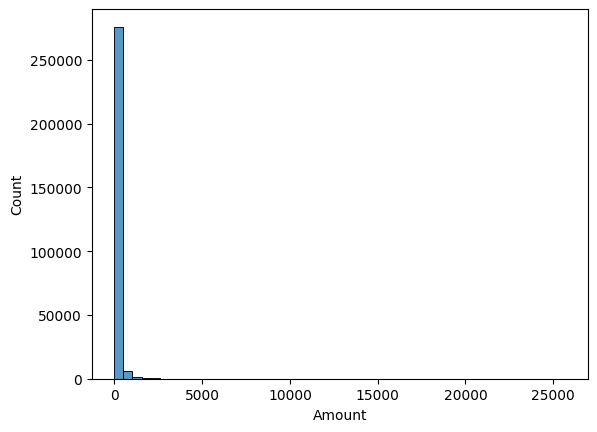

In [8]:
sns.histplot(df['Amount'], bins=50)
print(df['Amount'].describe())

We can conclude from the histogram that the distribution is highly positively skewed. Most transactions are small, while large transactions are very rare.

Now, we will check the distribution of the Time feature

<Axes: xlabel='Time', ylabel='Count'>

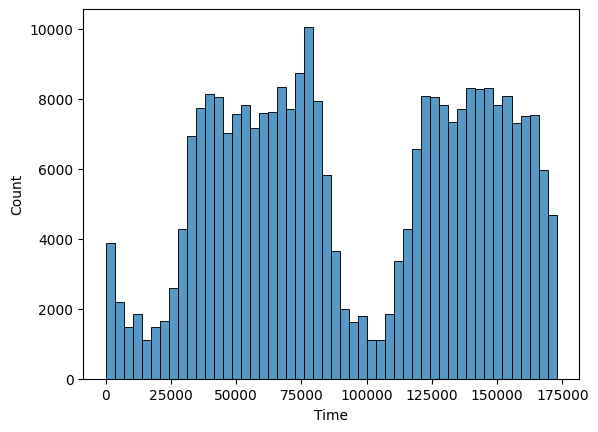

In [9]:
sns.histplot(df['Time'], bins=50)

We can see that the data exhibits a bimodal distribution, characterized by two distinct periods of high transaction volume separated by a trough. The first peak represents the first day, the second peak represents the second day and the trough represents the overnight between them.

<Axes: xlabel='Class', ylabel='Amount'>

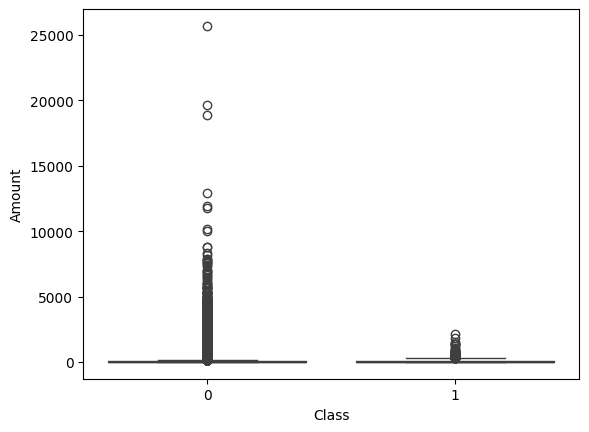

In [12]:
sns.boxplot(x='Class', y='Amount', data=df)

Conclusions:

Extreme Skew: The distribution is highly concentrated near $0, indicating that the vast majority of transactions are small.

Outlier Problem: The feature contains extreme high-value outliers (up to $$$25,000), which can severely distort models sensitive to scale and distance.

Predictive Value: Fraudulent transactions (Class 1) have a statistically higher median amount than normal transactions (Class 0), confirming the feature's importance.

<Axes: xlabel='V1', ylabel='Density'>

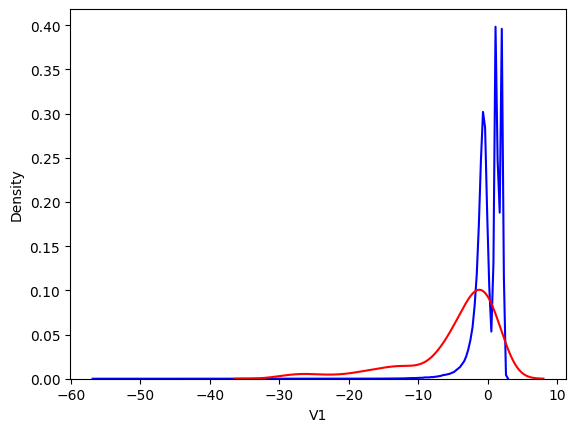

In [11]:
sns.kdeplot(df[df['Class'] == 0]['V1'], label='Normal', color='blue')
sns.kdeplot(df[df['Class'] == 1]['V1'], label='Fraud', color='red')

Conclusions:

Normal Data: Normal transactions (Blue curve) are highly dense and concentrated around the center of the V1 feature space.

Fraud Data: Fraudulent transactions (Red curve) are sparse and spread out over a much wider range, particularly toward the highly negative values.

Model Justification: This pattern confirms the suitability of Isolation Forest and OCSVM, as these algorithms excel at separating low-density, wide-ranging points (anomalies) from high-density clusters (normal data).

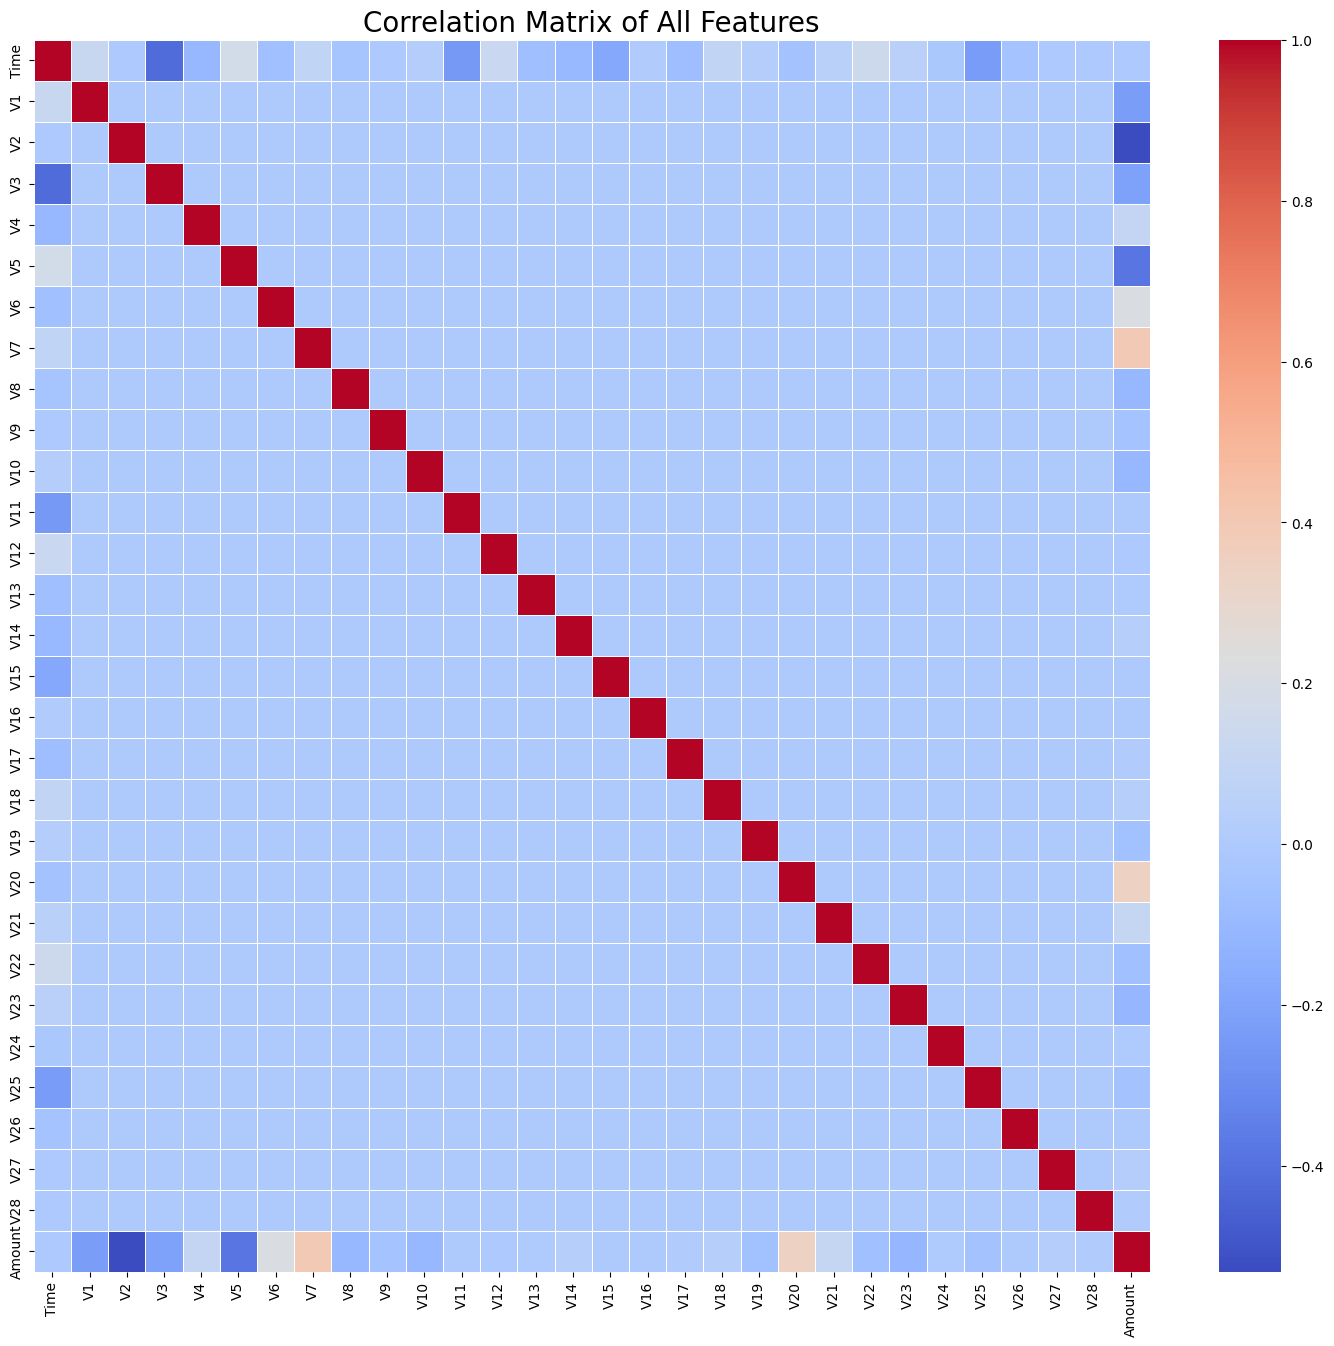

In [14]:
correlation_matrix = df.drop(columns=['Class']).corr()

# Plotting the heatmap
plt.figure(figsize=(18, 16)) # Use a large size due to 30 features
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=False, # Set to True to see values, but it clutters the plot
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Matrix of All Features', fontsize=20)
plt.show()

Due to the fact that the features are the result of a PCA, then sure there will be no correlation between the features as shown in the figure.

### DataPreprocessing

We will first split the dataset based on the class ( normal or not).

In [15]:
df_normal = df[df['Class'] == 0]
df_anomaly = df[df['Class'] == 1]

After that, we will split the normal data into training and testing sets (20% for testing).

In [16]:
df_normal_train, df_normal_test = train_test_split(
    df_normal, 
    test_size=0.2, 
    random_state=42
)

Now, combine the normal testset with the anomaly dataset.

In [17]:
df_test = pd.concat([df_normal_test, df_anomaly], ignore_index=True)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) #shuffling the whole dataset

After that, we will feature engineer the Time feature by replacing it with an Hour feature which represents the hour of the day at which the transaction happened instead of the time in seconds.

In [18]:
def engineer_time_feature(df_input):
    """Calculates the Hour of Day from the Time feature."""
    # Time is in seconds. 3600 seconds in an hour.
    df_output = df_input.copy()
    df_output['Hour'] = np.floor(df_output['Time'] / 3600) % 24
    df_output.drop('Time', axis=1, inplace=True)
    return df_output

df_normal_train = engineer_time_feature(df_normal_train)
df_test = engineer_time_feature(df_test)

The next step is scaling the unscales features which are the Amount and Hour. We will use robust scalar for the Amount feature because it contains outliers.

In [21]:
robust_scaler = RobustScaler()
robust_scaler.fit(df_normal_train[['Amount']])

df_normal_train['Amount'] = robust_scaler.transform(df_normal_train[['Amount']])
df_test['Amount'] = robust_scaler.transform(df_test[['Amount']])

In [22]:
standard_scaler = StandardScaler()
standard_scaler.fit(df_normal_train[['Hour']]) # Fit only on training data

df_normal_train['Hour'] = standard_scaler.transform(df_normal_train[['Hour']])
df_test['Hour'] = standard_scaler.transform(df_test[['Hour']])

Now, separate the list of final features from the class (label) because it is unsupervised learning and then at the end we can evaluate the model using the y_test

In [23]:
X_FEATURES = ['Amount', 'Hour'] + [f'V{i}' for i in range(1, 29)]

X_train_normal = df_normal_train[X_FEATURES]

X_test = df_test[X_FEATURES]
y_test = df_test['Class']

### Model Training and Evaluation
MODEL 1: Isolation Forest (iForest)

In [25]:
# Contamination is (Fraud Count / Total Count)
# Contamination = 492 / 284807 ≈ 0.001727
CONTAMINATION_FACTOR = 0.001727

iforest = IsolationForest(
    n_estimators=100,
    contamination=CONTAMINATION_FACTOR,
    random_state=42,
    n_jobs=-1  # Use all available cores for faster training
)

# Training: Fit the model ONLY on the PURE NORMAL training data
iforest.fit(X_train_normal)

# Prediction: Predict on the test set
# -1 means Anomaly (Fraud), 1 means Normal
y_pred_iforest = iforest.predict(X_test)

# Convert predictions to 0 (Normal) and 1 (Fraud) for classification report
y_pred_iforest_mapped = np.where(y_pred_iforest == -1, 1, 0)

MODEL 2: One-Class SVM (OCSVM)

In [26]:
ocsvm = OneClassSVM(
    kernel='rbf',
    nu=CONTAMINATION_FACTOR,
    gamma='auto' # Automatically calculates gamma for better performance
)

# Training: Fit the model ONLY on the PURE NORMAL training data
ocsvm.fit(X_train_normal)

# Prediction: Predict on the test set
y_pred_ocsvm = ocsvm.predict(X_test)

# Convert predictions to 0 (Normal) and 1 (Fraud)
y_pred_ocsvm_mapped = np.where(y_pred_ocsvm == -1, 1, 0)

In [27]:
def evaluate_model(y_true, y_pred, model_name):
    """Prints key anomaly detection metrics."""
    print(f"\n--- Evaluation Results for {model_name} ---")
    
    # Precision: Out of all predicted fraud, how many were actually fraud?
    precision = precision_score(y_true, y_pred)
    
    # Recall (Sensitivity): Out of all actual fraud, how many did we catch? (MOST IMPORTANT)
    recall = recall_score(y_true, y_pred)
    
    # F1-Score: Harmonic mean of Precision and Recall.
    f1 = f1_score(y_true, y_pred)
    
    print(f"Precision (Accuracy of Fraud Flags): {precision:.4f}")
    print(f"Recall (Fraud Detection Rate):       {recall:.4f}")
    print(f"F1-Score:                           {f1:.4f}")

# Evaluate Isolation Forest
evaluate_model(y_test, y_pred_iforest_mapped, "Isolation Forest")

# Evaluate One-Class SVM
evaluate_model(y_test, y_pred_ocsvm_mapped, "One-Class SVM")


--- Evaluation Results for Isolation Forest ---
Precision (Accuracy of Fraud Flags): 0.6154
Recall (Fraud Detection Rate):       0.2764
F1-Score:                           0.3815

--- Evaluation Results for One-Class SVM ---
Precision (Accuracy of Fraud Flags): 0.3907
Recall (Fraud Detection Rate):       0.8171
F1-Score:                           0.5286


As a conclusion from the evaluation results, One-Class SVM is better than Isolation Forest for the anomaly detection problem because it is way better at minimizing false negatives which is important for the anomaly detection.

For Anomaly Detection in Financial Transactions, Recall is almost always the most important metric.